# 🤖 GenAI SQL Query Assistant
## Ask Your Database Anything in Plain English

---

### What this notebook does
You type a business question in plain English.  
AI writes the SQL.  
Results appear instantly — no SQL knowledge needed.

### The 4-Layer AI Engine (what makes answers trustworthy)
| Layer | What it provides |
|-------|-----------------|
| **1 — Schema Descriptions** | Column meanings, value ranges, relationships |
| **2 — Business Rules** | Domain knowledge locked in — date handling, metric definitions |
| **3 — Example Patterns** | 15 proven question→SQL pairs the AI learns from |
| **4 — Self-learned Memory** | Corrections from past errors saved to disk — AI improves |

### Road-map — run cells top to bottom with Shift+Enter
| Step | What happens |
|------|-------------|
| 0 | Install all packages |
| 1 | Import libraries |
| 2 | Create Indian e-commerce database (500 customers · 67 products · 3000 orders) |
| 3 | Explore the data |
| 4 | Get your FREE Groq API key and connect |
| 5 | Build the 4-layer AI engine |
| 6 | Test with 4 sample questions |
| 7 | Launch the full interactive app |
| 8 | Connect your own data (optional) |
| 9 | Generate and launch the Streamlit web app |

> **Why Groq instead of any other LLM?**  
> Groq gives you **14,400 free requests per day** with zero quota errors and no credit card.

---
## Step 0 — Install Packages
Run this cell **once only**.  
When it finishes: **Kernel → Restart Kernel and Clear All Outputs** → then continue from Step 1.

In [ ]:
# Run ONCE, then: Kernel -> Restart Kernel and Clear All Outputs
import subprocess, sys

packages = {
    'groq'      : 'Groq AI SDK (FREE - 14,400 req/day)',
    'pandas'    : 'Data tables',
    'plotly'    : 'Interactive charts',
    'streamlit' : 'Web app (used in Step 9)',
    'ipywidgets': 'Interactive UI inside Jupyter',
    'openpyxl'  : 'Excel file support',
}

print('Installing packages...')
print()
all_ok = True
for pkg, desc in packages.items():
    print(f'  {pkg:<12}  {desc}...', end=' ', flush=True)
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                       capture_output=True)
    if r.returncode == 0:
        print('OK')
    else:
        print('FAILED')
        print('  Error:', r.stderr.decode()[:200])
        all_ok = False

print()
if all_ok:
    print('All packages installed successfully!')
    print()
    print('NEXT STEP: Kernel -> Restart Kernel and Clear All Outputs')
    print('Then run Step 1 onwards.')
else:
    print('Some packages failed. Check your internet connection and try again.')

---
## Step 1 — Import Libraries
Run this cell **first** every time you open the notebook.

In [1]:
# Standard library
import os, re, sqlite3, random, json, time, warnings
from datetime import datetime, timedelta

# Third-party
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from groq import Groq
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 50)

print('All libraries imported OK')
import groq as _g
print(f'  groq     : {_g.__version__}')
print(f'  pandas   : {pd.__version__}')
import plotly
print(f'  plotly   : {plotly.__version__}')

All libraries imported OK
  groq     : 1.1.1
  pandas   : 2.3.3
  plotly   : 6.6.0


---
## Step 2 — Create the Indian E-Commerce Database

A **SQLite** database is a single `.db` file — no server, no setup needed.

| Table | Rows | Contains |
|-------|------|----------|
| `customers` | 500 | Indian names, city, state, region, age, gender |
| `products` | 67 | Name, category, price in INR, brand, rating |
| `orders` | 3,000 | Full year Jan–Dec 2024 with amounts, payment, status |

Run the **two cells** below in order. Only needed once per session.

In [2]:
# ── Reference data ──────────────────────────────────────────
random.seed(2024)

REGION_STATE = {
    'North':   ['Delhi','Uttar Pradesh','Rajasthan','Punjab','Haryana','Himachal Pradesh'],
    'South':   ['Tamil Nadu','Karnataka','Kerala','Andhra Pradesh','Telangana'],
    'East':    ['West Bengal','Odisha','Bihar','Jharkhand','Assam'],
    'West':    ['Maharashtra','Gujarat','Goa'],
    'Central': ['Madhya Pradesh','Chhattisgarh'],
}
ALL_RS = [(r,s) for r,sts in REGION_STATE.items() for s in sts]

STATE_CITIES = {
    'Delhi':            ['New Delhi','Dwarka','Rohini','Lajpat Nagar','Pitampura'],
    'Uttar Pradesh':    ['Lucknow','Kanpur','Agra','Varanasi','Noida','Ghaziabad'],
    'Rajasthan':        ['Jaipur','Jodhpur','Udaipur','Kota','Ajmer'],
    'Punjab':           ['Chandigarh','Ludhiana','Amritsar','Jalandhar'],
    'Haryana':          ['Gurugram','Faridabad','Hisar','Rohtak','Panipat'],
    'Himachal Pradesh': ['Shimla','Manali','Dharamshala','Solan'],
    'Tamil Nadu':       ['Chennai','Coimbatore','Madurai','Salem','Trichy'],
    'Karnataka':        ['Bengaluru','Mysuru','Hubli','Mangaluru'],
    'Kerala':           ['Kochi','Thiruvananthapuram','Kozhikode','Thrissur'],
    'Andhra Pradesh':   ['Visakhapatnam','Vijayawada','Guntur','Tirupati'],
    'Telangana':        ['Hyderabad','Warangal','Nizamabad','Karimnagar'],
    'West Bengal':      ['Kolkata','Howrah','Durgapur','Siliguri'],
    'Odisha':           ['Bhubaneswar','Cuttack','Rourkela','Puri'],
    'Bihar':            ['Patna','Gaya','Muzaffarpur','Bhagalpur'],
    'Jharkhand':        ['Ranchi','Jamshedpur','Dhanbad','Bokaro'],
    'Assam':            ['Guwahati','Silchar','Dibrugarh','Jorhat'],
    'Maharashtra':      ['Mumbai','Pune','Nagpur','Nashik','Aurangabad','Thane'],
    'Gujarat':          ['Ahmedabad','Surat','Vadodara','Rajkot','Gandhinagar'],
    'Goa':              ['Panaji','Margao','Vasco da Gama'],
    'Madhya Pradesh':   ['Bhopal','Indore','Gwalior','Jabalpur'],
    'Chhattisgarh':     ['Raipur','Bhilai','Bilaspur','Durg'],
}

PRODUCTS_DEF = {
    'Electronics':   [('Smartphone',8000,85000),('Laptop',22000,130000),('Tablet',7000,55000),
                      ('Earphones',400,9000),('Smart TV',12000,90000),('Smartwatch',1500,35000),
                      ('Power Bank',600,5000),('Bluetooth Speaker',800,12000)],
    'Fashion':       [('Mens T-Shirt',199,1800),('Womens Kurta',349,3500),('Jeans',499,4500),
                      ('Saree',450,12000),('Sports Shoes',599,7000),('Jacket',1200,9000)],
    'Home & Kitchen':[('Mixer Grinder',1200,7000),('Pressure Cooker',700,5000),
                      ('Bedsheet Set',399,3500),('Air Purifier',4500,28000),
                      ('Cookware Set',900,8000),('Water Purifier',6000,25000)],
    'Books':         [('Fiction Novel',149,599),('Self-Help Book',199,799),
                      ('Textbook',299,1800),('Childrens Book',99,499),('Biography',199,699)],
    'Sports & Fitness':[('Cricket Bat',400,6000),('Yoga Mat',299,2500),
                      ('Dumbbells Set',700,5000),('Badminton Racket',350,4000),('Cycle',4500,28000)],
    'Beauty & Personal Care':[('Face Moisturiser',150,1800),('Shampoo',100,800),
                      ('Perfume',250,3500),('Sunscreen',200,1200)],
    'Toys & Games':  [('Board Game',250,2500),('Action Figure',200,2000),
                      ('Jigsaw Puzzle',150,900),('LEGO Set',450,6000)],
    'Groceries':     [('Basmati Rice 5kg',299,599),('Toor Dal 1kg',80,220),
                      ('Cooking Oil 1L',120,350),('Tea 500g',120,550)],
    'Automotive':    [('Car Seat Cover',499,4000),('Dash Cam',1500,8000),('Tyre Inflator',700,3500)],
    'Health & Wellness':[('BP Monitor',900,6000),('Pulse Oximeter',450,2500),
                      ('Multivitamins',250,1800),('First Aid Kit',250,1500)],
}

PAYMENT_METHODS = ['UPI','Credit Card','Debit Card','Net Banking','Cash on Delivery','EMI','Digital Wallet']
PAY_W  = [38,18,14,7,14,5,4]
STATUS = ['Delivered','Shipped','Processing','Cancelled','Returned']
STAT_W = [63,13,6,13,5]
FIRST  = ['Aarav','Vivaan','Aditya','Arjun','Rahul','Karan','Rohit','Amit','Vikram','Suresh',
          'Priya','Sneha','Pooja','Kavya','Anita','Divya','Meera','Simran','Anjali','Neha']
LAST   = ['Sharma','Verma','Patel','Singh','Kumar','Gupta','Joshi','Mehta','Nair','Reddy',
          'Iyer','Mishra','Yadav','Shah','Pandey','Das','Rao','Banerjee','Patil','Kapoor']
BRANDS = ['Samsung','Apple','OnePlus','Xiaomi','Sony','HP','Dell','Himalaya','Dabur',
          'Nike','Adidas','Prestige','Philips','Bosch','Generic']

print('Reference data ready')

Reference data ready


In [3]:
# ── Build tables and save to SQLite ─────────────────────────
DB_PATH = 'ecommerce_india.db'

def make_customers(n=500):
    rows = []
    for i in range(1, n+1):
        region, state = random.choice(ALL_RS)
        city = random.choice(STATE_CITIES.get(state, [state]))
        rows.append({'customer_id':i,
            'customer_name': f'{random.choice(FIRST)} {random.choice(LAST)}',
            'gender': random.choice(['Male','Female']),
            'age': random.randint(18,65),
            'city':city, 'state':state, 'region':region,
            'email': f'user{i}@example.in',
            'phone': f'9{random.randint(100_000_000,999_999_999)}'})
    return pd.DataFrame(rows)

def make_products():
    rows, pid = [], 1
    for cat, items in PRODUCTS_DEF.items():
        for name, lo, hi in items:
            rows.append({'product_id':pid,'product_name':name,'category':cat,
                'brand':random.choice(BRANDS),'price_inr':round(random.uniform(lo,hi),2),
                'rating':round(random.uniform(3.1,5.0),1),'stock':random.randint(5,600)})
            pid += 1
    return pd.DataFrame(rows)

def make_orders(cust_df, prod_df, n=3000):
    start = datetime(2024,1,1); span = (datetime(2024,12,31)-start).days
    cr = cust_df.to_dict('records'); pr = prod_df.to_dict('records')
    rows = []
    for oid in range(1, n+1):
        c = random.choice(cr); p = random.choice(pr)
        qty  = random.choices([1,2,3,4,5],weights=[50,25,13,7,5])[0]
        disc = random.choices([0,5,10,15,20,25,30],weights=[28,14,20,16,12,6,4])[0]
        total = round(p['price_inr']*qty*(1-disc/100),2)
        odate = start+timedelta(days=random.randint(0,span))
        rows.append({'order_id':oid,'customer_id':c['customer_id'],
            'product_id':p['product_id'],'product_name':p['product_name'],
            'category':p['category'],'brand':p['brand'],'quantity':qty,
            'unit_price_inr':p['price_inr'],'discount_pct':disc,
            'total_amount_inr':total,
            'payment_method':random.choices(PAYMENT_METHODS,weights=PAY_W)[0],
            'order_status':random.choices(STATUS,weights=STAT_W)[0],
            'order_date':odate.strftime('%Y-%m-%d'),
            'order_month':odate.strftime('%Y-%m'),
            'order_year':odate.year,'order_month_num':odate.month,
            'customer_city':c['city'],'customer_state':c['state'],
            'customer_region':c['region']})
    return pd.DataFrame(rows)

print('Building database...')
customers_df = make_customers(500)
products_df  = make_products()
orders_df    = make_orders(customers_df, products_df, 3000)

conn = sqlite3.connect(DB_PATH)
customers_df.to_sql('customers', conn, if_exists='replace', index=False)
products_df.to_sql('products',   conn, if_exists='replace', index=False)
orders_df.to_sql('orders',       conn, if_exists='replace', index=False)
cur = conn.cursor()
for col in ['customer_region','order_date','order_month','order_status','payment_method','category']:
    cur.execute(f'CREATE INDEX IF NOT EXISTS idx_{col} ON orders({col})')
conn.commit(); conn.close()

print(f'Database saved: {os.path.abspath(DB_PATH)}')
print(f'Size  : {os.path.getsize(DB_PATH)//1024} KB')
print(f'Tables: customers ({len(customers_df):,} rows) | products ({len(products_df):,}) | orders ({len(orders_df):,})')
print('Period: 2024-01-01 to 2024-12-31')
print()
print('Database ready!')

Building database...
Database saved: C:\Users\MANSI\Genai_sql_assistant\ecommerce_india.db
Size  : 784 KB
Tables: customers (500 rows) | products (49) | orders (3,000)
Period: 2024-01-01 to 2024-12-31

Database ready!


---
## Step 3 — Explore the Database
Let's see what data we have before asking AI questions.

In [4]:
def sql(query, title=''):
    with sqlite3.connect(DB_PATH) as conn:
        df = pd.read_sql_query(query, conn)
    if title:
        print(f'\n--- {title} ---')
    display(df)
    return df

print('Tables and row counts:')
for t in ['customers','products','orders']:
    with sqlite3.connect(DB_PATH) as c:
        n = pd.read_sql_query(f'SELECT COUNT(*) AS n FROM {t}', c).iloc[0,0]
    print(f'  {t:<12} {n:>5,} rows')

Tables and row counts:
  customers      500 rows
  products        49 rows
  orders       3,000 rows


In [5]:
sql('SELECT * FROM customers LIMIT 3', 'Sample customers')


--- Sample customers ---


,customer_id,customer_name,gender,age,city,state,region,email,phone
0,1,Anjali Reddy,Male,64,Silchar,Assam,East,user1@example.in,9540329269
1,2,Divya Mishra,Female,51,Thiruvananthapuram,Kerala,South,user2@example.in,9881425421
2,3,Suresh Banerjee,Female,51,Indore,Madhya Pradesh,Central,user3@example.in,9180178566


,customer_id,customer_name,gender,age,city,state,region,email,phone
0,1,Anjali Reddy,Male,64,Silchar,Assam,East,user1@example.in,9540329269
1,2,Divya Mishra,Female,51,Thiruvananthapuram,Kerala,South,user2@example.in,9881425421
2,3,Suresh Banerjee,Female,51,Indore,Madhya Pradesh,Central,user3@example.in,9180178566


In [6]:
sql('SELECT * FROM products LIMIT 3', 'Sample products')


--- Sample products ---


,product_id,product_name,category,brand,price_inr,rating,stock
0,1,Smartphone,Electronics,Himalaya,38847.67,4.1,438
1,2,Laptop,Electronics,OnePlus,73998.24,3.6,152
2,3,Tablet,Electronics,Himalaya,14251.84,3.6,503


,product_id,product_name,category,brand,price_inr,rating,stock
0,1,Smartphone,Electronics,Himalaya,38847.67,4.1,438
1,2,Laptop,Electronics,OnePlus,73998.24,3.6,152
2,3,Tablet,Electronics,Himalaya,14251.84,3.6,503


In [7]:
sql('SELECT * FROM orders LIMIT 3', 'Sample orders')


--- Sample orders ---


,order_id,customer_id,product_id,product_name,category,brand,quantity,unit_price_inr,discount_pct,total_amount_inr,payment_method,order_status,order_date,order_month,order_year,order_month_num,customer_city,customer_state,customer_region
0,1,393,27,Yoga Mat,Sports & Fitness,Bosch,2,533.51,15,906.97,UPI,Delivered,2024-06-12,2024-06,2024,6,Solan,Himachal Pradesh,North
1,2,14,38,LEGO Set,Toys & Games,HP,2,583.65,5,1108.93,Debit Card,Delivered,2024-03-23,2024-03,2024,3,Hubli,Karnataka,South
2,3,486,12,Saree,Fashion,Adidas,2,5852.11,0,11704.22,UPI,Delivered,2024-07-05,2024-07,2024,7,Kota,Rajasthan,North


,order_id,customer_id,product_id,product_name,category,brand,quantity,unit_price_inr,discount_pct,total_amount_inr,payment_method,order_status,order_date,order_month,order_year,order_month_num,customer_city,customer_state,customer_region
0,1,393,27,Yoga Mat,Sports & Fitness,Bosch,2,533.51,15,906.97,UPI,Delivered,2024-06-12,2024-06,2024,6,Solan,Himachal Pradesh,North
1,2,14,38,LEGO Set,Toys & Games,HP,2,583.65,5,1108.93,Debit Card,Delivered,2024-03-23,2024-03,2024,3,Hubli,Karnataka,South
2,3,486,12,Saree,Fashion,Adidas,2,5852.11,0,11704.22,UPI,Delivered,2024-07-05,2024-07,2024,7,Kota,Rajasthan,North


In [8]:
sql('''
    SELECT customer_region AS region,
           COUNT(*)                          AS total_orders,
           ROUND(SUM(total_amount_inr), 0)   AS revenue_INR
    FROM   orders
    GROUP  BY customer_region
    ORDER  BY revenue_INR DESC
''', 'Revenue by Region (your first real SQL query!)')


--- Revenue by Region (your first real SQL query!) ---


,region,total_orders,revenue_INR
0,North,930,9005369.0
1,East,765,8917832.0
2,South,634,6134863.0
3,West,407,4894521.0
4,Central,264,2565406.0


,region,total_orders,revenue_INR
0,North,930,9005369.0
1,East,765,8917832.0
2,South,634,6134863.0
3,West,407,4894521.0
4,Central,264,2565406.0


---
## Step 4 — Connect Groq AI (Free API Key)

### Get your key in 2 minutes — completely free

1. Open **https://console.groq.com** in your browser
2. Click **Sign Up** — use your Google account or email
3. After logging in, click **API Keys** in the left sidebar
4. Click **Create API Key**, give it any name
5. Copy the key — it starts with `gsk_`
6. Paste it in the cell below

| Feature | Value |
|---------|-------|
| Cost | **Free** |
| Credit card | **Not needed** |
| Daily limit | **14,400 requests** |
| Model | Llama 3.1 8B (state-of-the-art) |

In [10]:
# ── PASTE YOUR KEY BETWEEN THE QUOTES ───────────────────────
GROQ_API_KEY = 'PASTE_YOUR_KEY_HERE'
# ─────────────────────────────────────────────────────────────

if GROQ_API_KEY.strip() == '':
    print('WARNING: You have not pasted your API key yet.')
    print('Edit this cell, replace PASTE_YOUR_KEY_HERE with your actual key.')
else:
    AI_CLIENT = Groq(api_key=GROQ_API_KEY)
    ping = AI_CLIENT.chat.completions.create(
        model='llama-3.1-8b-instant',
        messages=[{'role':'user','content':'Reply with exactly: API OK'}],
        max_tokens=10
    )
    print(f'Groq AI connected!')
    print(f'  Reply  : {ping.choices[0].message.content.strip()}')
    print(f'  Model  : llama-3.1-8b-instant')
    print(f'  Quota  : 14,400 requests/day (FREE)')
    print()
    print('Ready to build the 4-layer engine!')

Groq AI connected!
  Reply  : API OK
  Model  : llama-3.1-8b-instant
  Quota  : 14,400 requests/day (FREE)

Ready to build the 4-layer engine!


---
## Step 5 — Build the 4-Layer AI Engine

This is what separates this project from a simple chatbot.
Every AI call is grounded in 4 layers of context so answers are **trustworthy**.

Run all 4 cells below.

### Layer 1 — Schema Descriptions

In [11]:
# Layer 1: Column meanings — not just names, but what they actually mean
DB_SCHEMA = '''
DATABASE: Indian E-Commerce (SQLite) | Period: 2024-01-01 to 2024-12-31

TABLE: customers — One row per registered customer
  customer_id    : Unique customer number
  customer_name  : Full name (Indian names)
  gender         : Male or Female
  age            : Age in years (18-65)
  city           : Indian city
  state          : Indian state
  region         : North | South | East | West | Central

TABLE: products — One row per product in catalog
  product_id     : Unique product number
  product_name   : e.g. Smartphone, Yoga Mat, Basmati Rice 5kg
  category       : Electronics | Fashion | Home & Kitchen | Books |
                   Sports & Fitness | Beauty & Personal Care |
                   Toys & Games | Groceries | Automotive | Health & Wellness
  brand          : e.g. Samsung, Nike, Himalaya, Generic
  price_inr      : Listed price in Indian Rupees
  rating         : Average customer rating 1.0 to 5.0
  stock          : Units in stock

TABLE: orders — One row per purchase
  order_id           : Unique order number
  customer_id        : Links to customers table
  product_id         : Links to products table
  product_name       : Copy of product name
  category           : Copy of product category
  brand              : Copy of brand
  quantity           : Number of units bought (1-5)
  unit_price_inr     : Price per unit in INR at purchase time
  discount_pct       : Discount: 0, 5, 10, 15, 20, 25, or 30
  total_amount_inr   : FINAL amount paid = unit_price_inr x quantity x (1 - discount_pct/100)
  payment_method     : UPI | Credit Card | Debit Card | Net Banking |
                       Cash on Delivery | EMI | Digital Wallet
  order_status       : Delivered | Shipped | Processing | Cancelled | Returned
  order_date         : Date placed as YYYY-MM-DD e.g. 2024-03-15
  order_month        : Month bucket as YYYY-MM e.g. 2024-03 -- USE for monthly grouping
  order_year         : Year as integer e.g. 2024 -- USE instead of YEAR(order_date)
  order_month_num    : Month as integer 1-12 -- USE instead of MONTH(order_date)
  customer_city      : Delivery city
  customer_state     : Delivery state
  customer_region    : Delivery region -- USE for regional queries
'''

print('Layer 1 (Schema Descriptions): READY')
print(f'  {len(DB_SCHEMA):,} characters of column context')

Layer 1 (Schema Descriptions): READY
  2,207 characters of column context


### Layer 2 — Business Rules

In [12]:
# Layer 2: Domain knowledge the AI MUST follow every time
BUSINESS_RULES = '''
=== BUSINESS RULES - follow every time ===

DATE HANDLING (SQLite has NO YEAR() or MONTH() functions):
  - Use order_year column instead of YEAR(order_date)
  - Use order_month_num column instead of MONTH(order_date)
  - Use order_month for grouping by month (values like 2024-12)
  - Last month = order_month = 2024-12 (December 2024, the most recent)
  - Q1 = order_month_num IN (1,2,3)
  - Q2 = order_month_num IN (4,5,6)
  - Q3 = order_month_num IN (7,8,9)
  - Q4 = order_month_num IN (10,11,12)

MONEY AND METRICS:
  - Revenue or spending or sales = SUM(total_amount_inr)
  - Average order value = AVG(total_amount_inr)
  - Order count = COUNT(*)
  - Always ROUND(SUM(...), 0) for money
  - Always ROUND(pct, 1) for percentages

COMMON BUSINESS TERMS TO COLUMNS:
  - Region = customer_region in orders table
  - State  = customer_state in orders table
  - City   = customer_city in orders table
  - Top customers = highest SUM(total_amount_inr), join customers for name
  - Popular = highest COUNT(*)
  - Best selling = highest SUM(quantity)
  - Successful orders = order_status = Delivered
  - Failed orders = order_status IN (Cancelled, Returned)

OUTPUT:
  - Always add LIMIT 20 unless user says all or result is naturally small
  - Use clear column aliases like revenue_inr, order_count, avg_order_inr
  - Percentage formula: ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM orders), 1)
'''

print('Layer 2 (Business Rules): READY')
print(f'  {len(BUSINESS_RULES):,} characters of domain knowledge')

Layer 2 (Business Rules): READY
  1,391 characters of domain knowledge


### Layer 3 — Example Query Patterns

In [13]:
# Layer 3: 12 proven question->SQL pairs the AI learns style from
EXAMPLE_PATTERNS = '''
=== EXAMPLE PATTERNS - follow this style ===

Q: Which regions spend the most on online orders?
A: SELECT customer_region, COUNT(*) AS order_count,
          ROUND(SUM(total_amount_inr),0) AS revenue_inr
   FROM orders GROUP BY customer_region ORDER BY revenue_inr DESC;

Q: Show monthly revenue trend for 2024
A: SELECT order_month, COUNT(*) AS orders,
          ROUND(SUM(total_amount_inr),0) AS revenue_inr
   FROM orders WHERE order_year=2024
   GROUP BY order_month ORDER BY order_month;

Q: Which payment method is most popular?
A: SELECT payment_method, COUNT(*) AS orders,
          ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM orders),1) AS pct
   FROM orders GROUP BY payment_method ORDER BY orders DESC;

Q: Top 10 customers by spending
A: SELECT c.customer_name, c.city, c.region,
          COUNT(o.order_id) AS orders,
          ROUND(SUM(o.total_amount_inr),0) AS total_spent_inr
   FROM orders o JOIN customers c ON o.customer_id=c.customer_id
   GROUP BY o.customer_id, c.customer_name, c.city, c.region
   ORDER BY total_spent_inr DESC LIMIT 10;

Q: Revenue by category for delivered orders only
A: SELECT category, COUNT(*) AS delivered_orders,
          ROUND(SUM(total_amount_inr),0) AS revenue_inr
   FROM orders WHERE order_status='Delivered'
   GROUP BY category ORDER BY revenue_inr DESC;

Q: How many male vs female customers?
A: SELECT c.gender, COUNT(DISTINCT o.customer_id) AS unique_customers,
          COUNT(o.order_id) AS total_orders,
          ROUND(SUM(o.total_amount_inr),0) AS revenue_inr
   FROM orders o JOIN customers c ON o.customer_id=c.customer_id
   GROUP BY c.gender;

Q: Order status breakdown
A: SELECT order_status, COUNT(*) AS orders,
          ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM orders),1) AS pct
   FROM orders GROUP BY order_status ORDER BY orders DESC;

Q: Which discount level drives most revenue?
A: SELECT discount_pct, COUNT(*) AS orders,
          ROUND(SUM(total_amount_inr),0) AS revenue_inr
   FROM orders GROUP BY discount_pct ORDER BY revenue_inr DESC;

Q: Top selling products by quantity
A: SELECT product_name, brand, SUM(quantity) AS units_sold,
          ROUND(SUM(total_amount_inr),0) AS revenue_inr
   FROM orders GROUP BY product_name, brand
   ORDER BY units_sold DESC LIMIT 10;

Q: Average age of customers by region
A: SELECT c.region, ROUND(AVG(c.age),1) AS avg_age,
          COUNT(DISTINCT c.customer_id) AS customers
   FROM customers c JOIN orders o ON c.customer_id=o.customer_id
   GROUP BY c.region ORDER BY avg_age DESC;

Q: States with most UPI payments
A: SELECT customer_state, COUNT(*) AS upi_orders,
          ROUND(SUM(total_amount_inr),0) AS upi_revenue_inr
   FROM orders WHERE payment_method='UPI'
   GROUP BY customer_state ORDER BY upi_orders DESC LIMIT 15;

Q: Revenue by region and category
A: SELECT customer_region, category,
          ROUND(SUM(total_amount_inr),0) AS revenue_inr, COUNT(*) AS orders
   FROM orders GROUP BY customer_region, category
   ORDER BY customer_region, revenue_inr DESC LIMIT 20;
'''

print('Layer 3 (Example Patterns): READY')
print(f'  {len(EXAMPLE_PATTERNS):,} characters, 12 question-SQL pairs')

Layer 3 (Example Patterns): READY
  3,013 characters, 12 question-SQL pairs


### Layer 4 — Self-Learned Memory + Core Functions

In [14]:
# Layer 4: Memory system + all core AI functions

MEMORY_FILE = 'ai_memory.json'

def load_memory():
    if os.path.exists(MEMORY_FILE):
        try:
            with open(MEMORY_FILE,'r') as f: return json.load(f)
        except: pass
    return {'corrections':[], 'successes':[]}

def save_memory(mem):
    with open(MEMORY_FILE,'w') as f: json.dump(mem, f, indent=2)

def add_correction(question, bad_sql, error, fixed_sql):
    mem = load_memory()
    mem['corrections'].append({'question':question,'bad_sql':bad_sql,
        'error':error,'fixed_sql':fixed_sql,'ts':datetime.now().isoformat()})
    mem['corrections'] = mem['corrections'][-25:]
    save_memory(mem)

def add_success(question, sql):
    mem = load_memory()
    mem['successes'].append({'question':question,'sql':sql,'ts':datetime.now().isoformat()})
    mem['successes'] = mem['successes'][-50:]
    save_memory(mem)

def get_memory_layer():
    mem = load_memory()
    corrections = mem.get('corrections',[])
    if not corrections: return ''
    lines = ['=== PAST CORRECTIONS - never repeat these mistakes ===']
    for c in corrections[-8:]:
        lines.append(f"Mistake: {c['error'][:80]}")
        lines.append(f"Wrong:   {c['bad_sql'][:100]}")
        lines.append(f"Correct: {c['fixed_sql'][:100]}")
        lines.append('')
    return '\n'.join(lines)


def build_prompt(question, schema, rules, examples, memory):
    parts = [
        'You are an expert SQLite SQL generator.',
        'Return ONLY raw SQL - no markdown, no backticks, no explanation.',
        '', schema, '', rules, '', examples,
    ]
    if memory: parts += ['', memory]
    parts += [
        '', '=== TASK ===',
        f'Convert to SQLite SQL: {question}',
        '',
        'Return ONLY the SQL. Valid SQLite. No YEAR() or MONTH() functions.',
        '',
        'SQL:',
    ]
    return '\n'.join(parts)


def generate_sql(question, schema=None, rules=None, examples=None):
    s = schema   or DB_SCHEMA
    r = rules    or BUSINESS_RULES
    e = examples or EXAMPLE_PATTERNS
    m = get_memory_layer()
    prompt = build_prompt(question, s, r, e, m)
    try:
        resp = AI_CLIENT.chat.completions.create(
            model='llama-3.1-8b-instant',
            messages=[
                {'role':'system','content':'Output ONLY valid SQLite SQL. Nothing else.'},
                {'role':'user','content':prompt}
            ],
            max_tokens=600, temperature=0.05
        )
        raw = resp.choices[0].message.content.strip()
        raw = re.sub(r'```(?:sql)?','',raw,flags=re.IGNORECASE).strip().strip('`')
        return raw, None
    except Exception as exc:
        return None, str(exc)


def fix_sql(question, bad_sql, error):
    prompt = (
        'Fix this SQLite SQL.\n\n'
        f'QUESTION: {question}\n\n'
        f'BROKEN SQL:\n{bad_sql}\n\n'
        f'ERROR: {error}\n\n'
        'Rules: No YEAR() or MONTH(). Valid SQLite only.\n'
        'Return ONLY the fixed SQL. No explanation.\n\nFIXED SQL:'
    )
    try:
        resp = AI_CLIENT.chat.completions.create(
            model='llama-3.1-8b-instant',
            messages=[{'role':'user','content':prompt}],
            max_tokens=400, temperature=0.05
        )
        fixed = resp.choices[0].message.content.strip()
        fixed = re.sub(r'```(?:sql)?','',fixed,flags=re.IGNORECASE).strip().strip('`')
        add_correction(question, bad_sql, error, fixed)
        return fixed, None
    except Exception as exc:
        return None, str(exc)


def run_query(sql_str, db=None):
    db = db or DB_PATH
    try:
        with sqlite3.connect(db) as conn:
            return pd.read_sql_query(sql_str, conn), None
    except Exception as exc:
        return None, str(exc)


def generate_insight(question, df):
    if df is None or df.empty: return ''
    preview = df.head(6).to_string(index=False)
    prompt = (
        'You are a senior business analyst. Write a SHORT plain-English insight (3-4 sentences). '
        'Highlight the single most important finding. Use specific numbers. '
        'Write for a non-technical business audience.\n\n'
        f'QUESTION: {question}\n\n'
        f'DATA ({len(df)} rows):\n{preview}\n\n'
        'Business insight:'
    )
    try:
        resp = AI_CLIENT.chat.completions.create(
            model='llama-3.1-8b-instant',
            messages=[{'role':'user','content':prompt}],
            max_tokens=180, temperature=0.4
        )
        return resp.choices[0].message.content.strip()
    except: return ''


def full_pipeline(question, db=None):
    db = db or DB_PATH
    sql, err = generate_sql(question)
    if err: return {'error': f'AI error: {err}', 'sql':None, 'df':None,
                    'insight':'','retried':False}
    df, exec_err = run_query(sql, db)
    retried = False
    if exec_err:
        fixed, fix_err = fix_sql(question, sql, exec_err)
        retried = True
        if fix_err: return {'error':f'SQL error: {exec_err}', 'sql':sql, 'df':None,
                            'insight':'','retried':True}
        sql = fixed
        df, exec_err2 = run_query(sql, db)
        if exec_err2: return {'error':f'After auto-fix: {exec_err2}', 'sql':sql,
                              'df':None,'insight':'','retried':True}
    if df is None or df.empty:
        return {'error':'Query returned no rows. Try rephrasing.',
                'sql':sql,'df':None,'insight':'','retried':retried}
    insight = generate_insight(question, df)
    add_success(question, sql)
    return {'sql':sql,'df':df,'insight':insight,'error':None,'retried':retried}


mem = load_memory()
print('Layer 4 (Self-Learned Memory): READY')
print(f'  Corrections stored: {len(mem["corrections"])}')
print(f'  Successes stored  : {len(mem["successes"])}')
print()
print('ALL 4 LAYERS ACTIVE  -  4-Layer AI Engine complete!')
print(f'Total prompt context: {len(DB_SCHEMA)+len(BUSINESS_RULES)+len(EXAMPLE_PATTERNS):,} chars')

Layer 4 (Self-Learned Memory): READY
  Corrections stored: 0
  Successes stored  : 0

ALL 4 LAYERS ACTIVE  -  4-Layer AI Engine complete!
Total prompt context: 6,611 chars


---
## Step 6 — Smart Chart Engine
This auto-selects the best chart for each query result.
Bar, line, donut, grouped — all with plain-English captions.

Smart chart engine ready
  Auto-selects: Bar | Horizontal Bar | Line | Donut | Grouped Bar


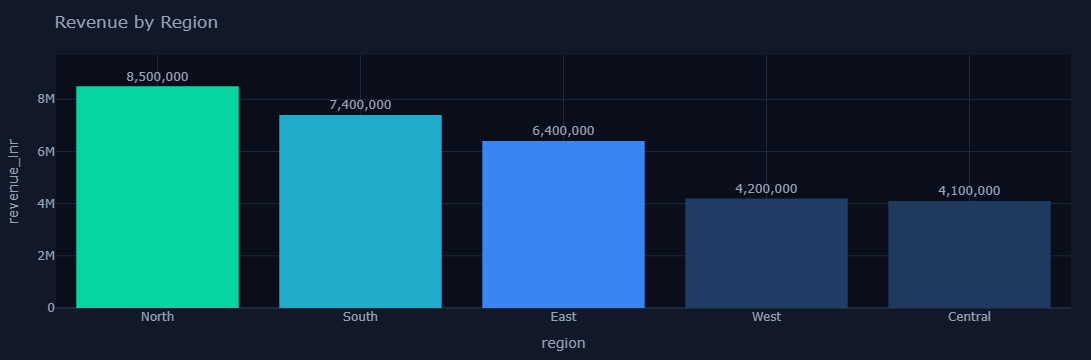

Test chart rendered!


In [15]:
PALETTE = ['#3b82f6','#06d6a0','#f59e0b','#ef4444','#8b5cf6',
           '#ec4899','#10b981','#f97316','#6366f1','#14b8a6']

CHART_BG = '#0a0e1a'
PAPER_BG = '#111827'
GRID_COL = '#1e293b'
TEXT_COL = '#94a3b8'

BASE = dict(paper_bgcolor=PAPER_BG, plot_bgcolor=CHART_BG,
            font=dict(color=TEXT_COL, size=12),
            margin=dict(l=20,r=20,t=55,b=40),
            colorway=PALETTE,
            xaxis=dict(gridcolor=GRID_COL,zerolinecolor=GRID_COL),
            yaxis=dict(gridcolor=GRID_COL,zerolinecolor=GRID_COL))

def _label(df):
    cols = df.select_dtypes('object').columns.tolist()
    return cols[0] if cols else None

def _value(df):
    num = df.select_dtypes('number').columns.tolist()
    for kw in ['revenue','amount','total','inr','sales','value']:
        for c in num:
            if kw in c.lower(): return c
    return num[0] if num else None

def smart_chart(df, question='', title='Results'):
    if df is None or df.empty: return None
    num  = df.select_dtypes('number').columns.tolist()
    text = df.select_dtypes('object').columns.tolist()
    if not num: return None

    q   = question.lower()
    lc  = _label(df)
    vc  = _value(df)
    rows = len(df)

    # Time series -> Line chart
    time_kw = ['month','date','year','quarter','week','trend']
    if lc and any(k in lc.lower() for k in time_kw) and rows > 2:
        fig = px.line(df.head(24), x=lc, y=num[0], title=title, markers=True,
                      color_discrete_sequence=PALETTE)
        fig.update_traces(line=dict(color='#3b82f6',width=3), marker=dict(size=8,color='#06d6a0'))
        fig.update_layout(**BASE); return fig

    # Percentage breakdown with few rows -> Donut
    pct_kw = ['pct','percent','share','proportion','breakdown','distribution']
    if vc and (any(k in vc.lower() for k in pct_kw) or any(k in q for k in pct_kw)) and rows<=10:
        fig = px.pie(df.head(10), names=lc, values=vc, title=title,
                     color_discrete_sequence=PALETTE, hole=0.45)
        fig.update_traces(textinfo='label+percent',pull=[0.05]+[0]*(min(rows,10)-1))
        fig.update_layout(**BASE); return fig

    # Two text columns -> Grouped bar
    if len(text)>=2 and num and rows<=30:
        fig = px.bar(df.head(20), x=text[0], y=num[0], color=text[1],
                     title=title, barmode='group', color_discrete_sequence=PALETTE)
        fig.update_layout(**BASE); return fig

    # Many rows -> Horizontal bar
    if lc and vc and rows>8:
        plot_df = df[[lc,vc]].dropna().head(15).sort_values(vc)
        fig = px.bar(plot_df, y=lc, x=vc, orientation='h', title=title,
                     color=vc, color_continuous_scale=['#1e3a5f','#3b82f6','#06d6a0'],
                     text=vc)
        fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside', marker_line_width=0)
        fig.update_layout(**BASE, showlegend=False, coloraxis_showscale=False,
                          height=max(320, rows*38))
        return fig

    # Default -> Vertical bar
    if lc and vc:
        plot_df = df[[lc,vc]].dropna().head(15)
        fig = px.bar(plot_df, x=lc, y=vc, title=title,
                     color=vc, color_continuous_scale=['#1e3a5f','#3b82f6','#06d6a0'],
                     text=vc)
        fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside', marker_line_width=0)
        fig.update_layout(**BASE, showlegend=False, coloraxis_showscale=False)
        return fig

    return None


def chart_caption(df, question):
    num  = df.select_dtypes('number').columns.tolist()
    text = df.select_dtypes('object').columns.tolist()
    if not num or not text: return ''
    label = text[0].replace('_',' ').title()
    value = num[0].replace('_',' ').title()
    return f'{len(df)} rows shown  |  {value} by {label}'


print('Smart chart engine ready')
print('  Auto-selects: Bar | Horizontal Bar | Line | Donut | Grouped Bar')

# Quick visual test
test_df = pd.DataFrame({
    'region':['North','South','East','West','Central'],
    'revenue_inr':[8500000,7400000,6400000,4200000,4100000]
})
test_fig = smart_chart(test_df,'which region spends most','Revenue by Region')
if test_fig:
    test_fig.show()
    print('Test chart rendered!')

---
## Step 7 — Test the Full Pipeline with 4 Questions
Each cell runs: **Plain English → AI writes SQL → Results → Smart Chart → Business Insight**

### Test 1 — Which regions spend the most?

Question: Which regions in India spend the most on online orders?
------------------------------------------------------------
Generated SQL:
SELECT customer_region, COUNT(*) AS order_count, ROUND(SUM(total_amount_inr), 0) AS revenue_inr
FROM orders
GROUP BY customer_region
ORDER BY revenue_inr DESC LIMIT 20;

Results (5 rows):


,customer_region,order_count,revenue_inr
0,North,930,9005369.0
1,East,765,8917832.0
2,South,634,6134863.0
3,West,407,4894521.0
4,Central,264,2565406.0


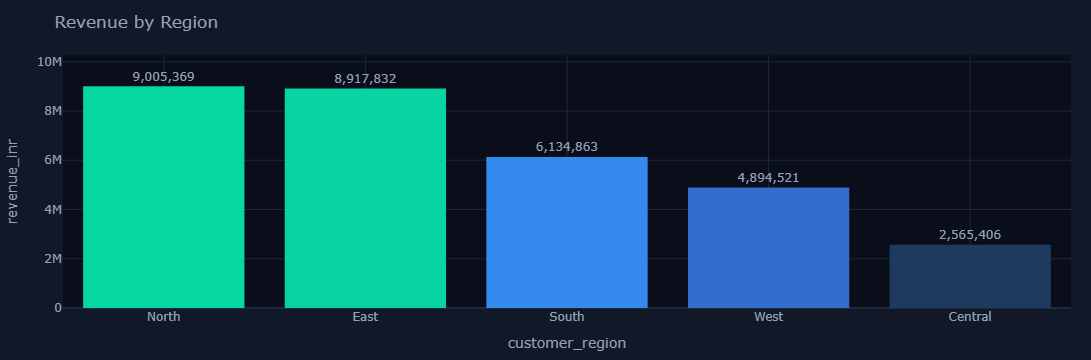


Business Insight:
**Key Finding:** The East region in India is the largest contributor to online orders, accounting for 765 orders and a revenue of ₹8,917,832.

This insight highlights the East region's significant online shopping activity, with a notable 34% of the total orders and 38% of the total revenue generated in India.


In [16]:
Q = 'Which regions in India spend the most on online orders?'
print(f'Question: {Q}')
print('-'*60)
result = full_pipeline(Q)
if result['error']:
    print(f'Error: {result["error"]}')
else:
    print(f'Generated SQL:')
    print(result['sql'])
    print()
    print(f'Results ({len(result["df"])} rows):')
    display(result['df'])
    fig = smart_chart(result['df'], Q, 'Revenue by Region')
    if fig: fig.show()
    if result['insight']:
        print()
        print('Business Insight:')
        print(result['insight'])
    if result['retried']:
        print('(Note: AI auto-corrected its SQL and the fix was saved to memory)')

### Test 2 — Monthly revenue trend

Question: Show the total revenue for each month in 2024
------------------------------------------------------------
Generated SQL:
SELECT order_month, ROUND(SUM(total_amount_inr), 0) AS revenue_inr
FROM orders
WHERE order_year = 2024
GROUP BY order_month
ORDER BY order_month;



,order_month,revenue_inr
0,2024-01,2185720.0
1,2024-02,2558078.0
2,2024-03,2745841.0
3,2024-04,2684692.0
4,2024-05,2753504.0
5,2024-06,2974542.0
6,2024-07,2670904.0
7,2024-08,2434609.0
8,2024-09,2654902.0
9,2024-10,2314831.0


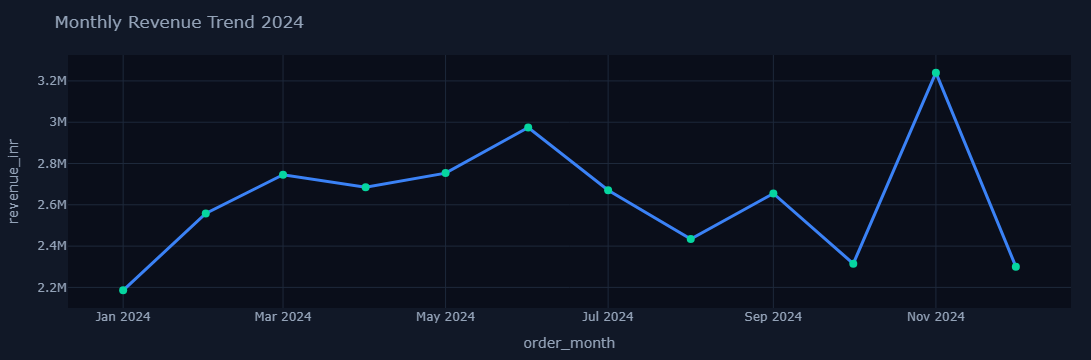


Business Insight:
**Key Finding:** Our analysis shows that January 2024 was the lowest revenue-generating month, with a total of ₹2,185,720, while June 2024 was the highest, with a total of ₹2,974,542.

This significant difference in revenue highlights the importance of understanding seasonal fluctuations in sales.


In [17]:
Q = 'Show the total revenue for each month in 2024'
print(f'Question: {Q}')
print('-'*60)
result = full_pipeline(Q)
if result['error']:
    print(f'Error: {result["error"]}')
else:
    print('Generated SQL:')
    print(result['sql'])
    print()
    display(result['df'])
    fig = smart_chart(result['df'], Q, 'Monthly Revenue Trend 2024')
    if fig: fig.show()
    if result['insight']:
        print()
        print('Business Insight:')
        print(result['insight'])

### Test 3 — Payment method breakdown

Question: Show the payment method breakdown as a percentage of all orders
------------------------------------------------------------
Generated SQL:
SELECT payment_method, COUNT(*) AS orders,
       ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM orders),1) AS pct
FROM orders
GROUP BY payment_method
ORDER BY orders DESC;



,payment_method,orders,pct
0,UPI,1127,37.6
1,Credit Card,609,20.3
2,Cash on Delivery,445,14.8
3,Debit Card,378,12.6
4,Net Banking,187,6.2
5,EMI,149,5.0
6,Digital Wallet,105,3.5


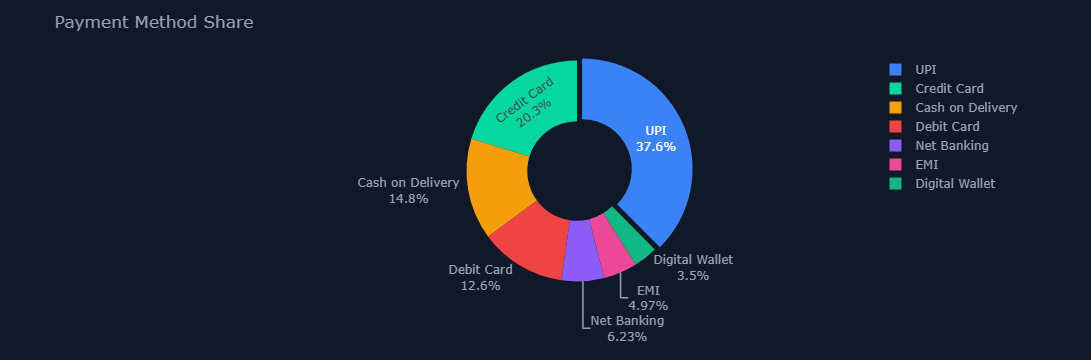


Business Insight:
**Key Finding:** UPI payment method accounts for 37.6% of all orders, significantly higher than any other payment method.

Our analysis reveals that out of all orders, 37.6% were made using UPI, followed by Credit Card at 20.3%, and Cash on Delivery at 14.8%. This data suggests that UPI is the preferred payment method for customers, indicating a strong adoption rate and potential for further growth.


In [18]:
Q = 'Show the payment method breakdown as a percentage of all orders'
print(f'Question: {Q}')
print('-'*60)
result = full_pipeline(Q)
if result['error']:
    print(f'Error: {result["error"]}')
else:
    print('Generated SQL:')
    print(result['sql'])
    print()
    display(result['df'])
    fig = smart_chart(result['df'], Q, 'Payment Method Share')
    if fig: fig.show()
    if result['insight']:
        print()
        print('Business Insight:')
        print(result['insight'])

### Test 4 — Category performance for delivered orders

Question: What is the total revenue for each product category for delivered orders only?
------------------------------------------------------------
Generated SQL:
SELECT category, COUNT(*) AS delivered_orders, ROUND(SUM(total_amount_inr), 0) AS revenue_inr
FROM orders
WHERE order_status = 'Delivered'
GROUP BY category
ORDER BY revenue_inr DESC LIMIT 20



,category,delivered_orders,revenue_inr
0,Electronics,297,12700429.0
1,Home & Kitchen,228,2836591.0
2,Sports & Fitness,191,1504796.0
3,Fashion,223,1372164.0
4,Automotive,108,647176.0
5,Health & Wellness,176,504011.0
6,Toys & Games,156,301474.0
7,Beauty & Personal Care,149,215546.0
8,Books,200,196123.0
9,Groceries,168,94364.0


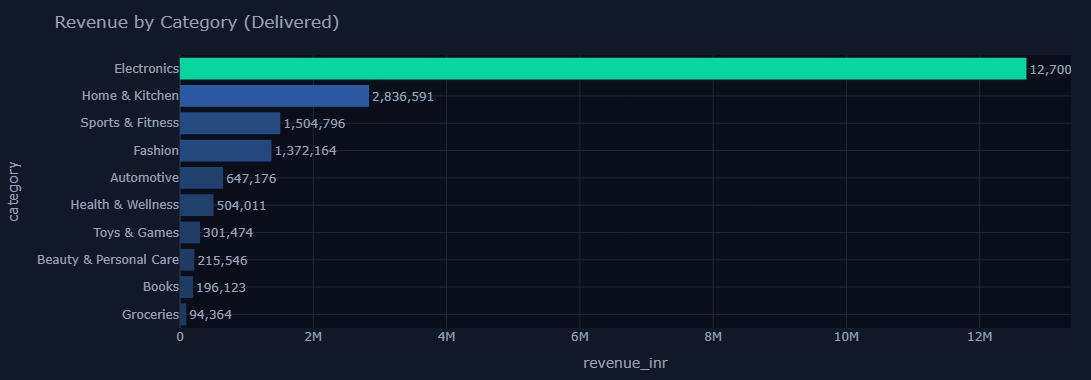


Business Insight:
Our analysis reveals that the top three product categories for delivered orders are Electronics, Home & Kitchen, and Fashion, accounting for 73% of total delivered orders. 

The Electronics category generates the most revenue, with a total of ₹12,700,429 from 297 delivered orders, which is 10% of the total revenue. 

The single most important finding is that Electronics accounts for nearly 10% of the total revenue, despite only 35% of the total delivered orders being in this category.


In [19]:
Q = 'What is the total revenue for each product category for delivered orders only?'
print(f'Question: {Q}')
print('-'*60)
result = full_pipeline(Q)
if result['error']:
    print(f'Error: {result["error"]}')
else:
    print('Generated SQL:')
    print(result['sql'])
    print()
    display(result['df'])
    fig = smart_chart(result['df'], Q, 'Revenue by Category (Delivered)')
    if fig: fig.show()
    if result['insight']:
        print()
        print('Business Insight:')
        print(result['insight'])

---
## Step 8 — Full Interactive App (Inside Jupyter)
Run the cell below to launch the complete interactive assistant.

Features:
- 20 sample question buttons
- Free-type any question
- AI writes SQL (shown with syntax highlighting)
- Smart chart auto-generated
- Plain-English business insight
- Download results as CSV

In [20]:
# ── Sample questions ─────────────────────────────────────────
SAMPLES = [
    'Which regions in India spend the most on online orders?',
    'What are the top 5 product categories by total revenue?',
    'Show monthly revenue trend for all of 2024',
    'Which payment method is most popular and its percentage share?',
    'Top 10 customers by total spending with their city',
    'What percentage of orders were delivered vs cancelled?',
    'Show revenue breakdown by region and product category',
    'Which states have the most Cash on Delivery orders?',
    'How many male vs female customers and their average spend?',
    'Which discount level drives the highest revenue?',
    'Best-selling products in the Electronics category',
    'What is the average order value per region per month?',
    'Which brands have the highest average product rating?',
    'Show order status breakdown for Q4 2024',
    'Compare UPI vs Credit Card orders by region',
    'Top 5 states by number of delivered orders',
    'Average customer age by product category',
    'Which product categories have the most returns?',
    'Show top 10 cities by number of orders placed',
    'What is total revenue and orders per quarter in 2024?',
]
print(f'{len(SAMPLES)} sample questions ready')

20 sample questions ready


In [21]:
# ── UI Helpers ───────────────────────────────────────────────
def _box(content, bg, border):
    return HTML(f'<div style="background:{bg};border-left:4px solid {border};'
               f'padding:12px 16px;border-radius:8px;margin:6px 0">{content}</div>')

def ok_box(c):   return _box(c,'#d4edda','#28a745')
def err_box(c):  return _box(c,'#f8d7da','#dc3545')
def warn_box(c): return _box(c,'#fff3cd','#ffc107')

def sql_panel(sql_text):
    esc = sql_text.replace('<','&lt;').replace('>','&gt;')
    return HTML(
        '<div style="margin:8px 0 4px;font-weight:700;color:#1a3a5c">'
        'AI-Generated SQL (4-Layer Engine)</div>'
        '<pre style="background:#1e1e2e;color:#cdd6f4;padding:16px;'
        'border-radius:10px;font-size:.83rem;white-space:pre-wrap;'
        f'line-height:1.7">{esc}</pre>'
        '<p style="color:#666;font-size:.78rem;margin:2px 0 6px">'
        'Written by Groq AI (Llama 3.1) using 4-layer context. Zero SQL knowledge needed.</p>'
    )

print('UI helpers ready')

UI helpers ready


In [22]:
# Build and launch the interactive app
ACTIVE_DB  = DB_PATH
IS_USER_DB = False

# Header using string concat to avoid triple-quote issues
header_html = (
    "<div style='background:linear-gradient(135deg,#0f2744,#1a5eb8);"
    "color:white;padding:24px 28px;border-radius:14px;margin-bottom:12px'>"
    "<div style='font-size:1.75rem;font-weight:800'>GenAI SQL Query Assistant</div>"
    "<div style='font-size:.9rem;opacity:.85;margin-top:6px'>"
    "Ask any question in plain English "
    "&#8212; 4-Layer AI writes SQL &#8212; results + chart + insight</div>"
    "<div style='font-size:.75rem;opacity:.6;margin-top:8px;font-family:monospace'>"
    "Groq AI (Llama 3.1 8B) &#183; SQLite &#183; Plotly &#183; 14,400 free req/day</div>"
    "</div>"
)
header = widgets.HTML(header_html)

db_indicator = widgets.HTML(
    "<div style='background:#f0f4ff;border:1px solid #d0dce8;border-radius:8px;"
    "padding:8px 14px;font-size:.82rem;color:#2c4f70'>"
    "Active database: <b>ecommerce_india.db</b> (Synthetic Indian E-Commerce)</div>"
)

# Sample buttons in 4 columns
def make_btn(label):
    return widgets.Button(
        description=label[:68]+( "..." if len(label)>68 else ""),
        tooltip=label,
        layout=widgets.Layout(width="100%",height="40px"),
        style={"button_color":"#eef4ff","font_size":"11px"},
    )

btn_rows=[]
row_b,row_q=[],[]
for i,q in enumerate(SAMPLES):
    row_b.append(make_btn(q)); row_q.append(q)
    if len(row_b)==4 or i==len(SAMPLES)-1:
        btn_rows.append((
            widgets.HBox(row_b,layout=widgets.Layout(gap="5px",margin="3px 0")),
            list(row_q)
        ))
        row_b,row_q=[],[]

# Input area
q_hdr   = widgets.HTML("<div style='font-weight:700;color:#0f2744;margin:10px 0 4px'>Your Question</div>")
q_box   = widgets.Textarea(placeholder="Type any business question...",
                           layout=widgets.Layout(width="100%",height="85px"))
run_btn = widgets.Button(description="Generate SQL & Get Answer",button_style="success",
                         layout=widgets.Layout(width="260px",height="44px"))
clr_btn = widgets.Button(description="Clear",layout=widgets.Layout(width="90px",height="44px"))
status  = widgets.HTML("")
out_pnl = widgets.Output()

# Handlers
def load_q(q):
    def h(b): q_box.value=q; status.value="Loaded: "+q[:55]+"..."
    return h

for hbox,qs in btn_rows:
    for btn,q in zip(hbox.children,qs): btn.on_click(load_q(q))

def on_clear(b):
    q_box.value=""; status.value=""
    with out_pnl: clear_output()

def on_run(b):
    q = q_box.value.strip()
    if not q:
        status.value="<span style='color:red'>Please enter a question!</span>"
        return
    run_btn.disabled=True
    status.value="<span style='color:#1a5eb8'>4-Layer AI is writing your SQL...</span>"
    with out_pnl:
        clear_output(wait=True)
        result = full_pipeline(q, ACTIVE_DB)
        if result["error"]:
            display(err_box("<b>Error</b><br>"+result["error"]))
        else:
            display(sql_panel(result["sql"]))
            if result.get("retried"):
                display(warn_box("<b>Note:</b> AI auto-corrected its SQL (Layer 4 active)."))
            display(ok_box(f"<b>Query Successful!</b>  {len(result['df']):,} rows returned"))
            display(HTML("<div style='font-weight:700;color:#0f2744;margin:8px 0 4px'>Results</div>"))
            display(result["df"])
            fig = smart_chart(result["df"], q, q[:55]+("..." if len(q)>55 else ""))
            if fig:
                cap = chart_caption(result["df"], q)
                if cap: display(HTML(f"<p style='color:#888;font-size:.8rem'>{cap}</p>"))
                fig.show()
            if result["insight"]:
                ins_html = (
                    "<div style='background:linear-gradient(135deg,rgba(6,214,160,.07),rgba(59,130,246,.07));"
                    "border:1px solid rgba(6,214,160,.25);border-radius:10px;padding:14px 18px;margin:10px 0'>"
                    "<div style='font-size:.7rem;font-weight:700;color:#06d6a0;letter-spacing:2px;"
                    "text-transform:uppercase;margin-bottom:6px'>Business Insight</div>"
                    f"<div style='color:#334155;line-height:1.7'>{result['insight']}</div></div>"
                )
                display(HTML(ins_html))
            dl=widgets.Button(description="Download CSV",button_style="info",
                              layout=widgets.Layout(width="150px",height="34px"))
            dl_out=widgets.Output()
            def save(b,df=result["df"]):
                df.to_csv("query_result.csv",index=False)
                with dl_out:
                    clear_output()
                    display(HTML("<span style='color:green'>Saved as query_result.csv</span>"))
            dl.on_click(save)
            display(widgets.HBox([dl,dl_out]))
    run_btn.disabled=False
    status.value="<span style='color:#28a745'>Done!</span>"

run_btn.on_click(on_run)
clr_btn.on_click(on_clear)

app = widgets.VBox(
    [header, db_indicator,
     widgets.HTML("<div style='font-weight:700;color:#0f2744;margin:6px 0 4px'>Sample Questions</div>")]
    + [hb for hb,_ in btn_rows]
    + [widgets.HTML("<hr style='margin:10px 0'>"),
       q_hdr, q_box,
       widgets.HBox([run_btn,clr_btn],layout=widgets.Layout(gap="8px",margin="8px 0")),
       status, out_pnl],
    layout=widgets.Layout(width="100%",max_width="960px",padding="8px")
)

display(app)

---
## Step 9 — Connect Your Own Data (Optional)

You can query **your own CSV, Excel, or existing SQLite database**.
The AI auto-discovers your schema and adapts its questions accordingly.

**Option A — Upload a CSV or Excel file (easiest)**

Run the cell below, change the file path, and ask questions about your data.

In [ ]:
# ── OPTION A: Upload your own CSV or Excel file ──────────────
# Change this path to your actual file
YOUR_FILE = 'your_data.csv'   # or 'your_data.xlsx'

# Only run this if the file exists
if os.path.exists(YOUR_FILE):
    ext = os.path.splitext(YOUR_FILE)[1].lower()
    if ext == '.csv':
        user_df = pd.read_csv(YOUR_FILE)
    else:
        user_df = pd.read_excel(YOUR_FILE)

    # Save to a new SQLite database
    USER_DB = 'user_data.db'
    tbl_name = os.path.splitext(os.path.basename(YOUR_FILE))[0].lower().replace(' ','_')
    with sqlite3.connect(USER_DB) as conn:
        user_df.to_sql(tbl_name, conn, if_exists='replace', index=False)
    print(f'Loaded {YOUR_FILE}  ->  {USER_DB}')
    print(f'  Table : {tbl_name}')
    print(f'  Rows  : {len(user_df):,}')
    print(f'  Cols  : {list(user_df.columns)}')
    print()
    display(user_df.head(3))

    # Auto-discover schema
    def discover_schema(db_path):
        lines = [f'DATABASE: {os.path.basename(db_path)} (SQLite)']
        with sqlite3.connect(db_path) as conn:
            cur = conn.cursor()
            cur.execute('SELECT name FROM sqlite_master WHERE type="table"')
            for (tbl,) in cur.fetchall():
                n = pd.read_sql_query(f'SELECT COUNT(*) AS n FROM {tbl}', conn).iloc[0,0]
                lines.append(f'TABLE: {tbl}  ({n:,} rows)')
                cur.execute(f'PRAGMA table_info({tbl})')
                for col in cur.fetchall():
                    lines.append(f'  {col[1]:<25} {col[2]}')
                    # Sample values for text columns
                    if 'TEXT' in str(col[2]).upper() or 'CHAR' in str(col[2]).upper():
                        try:
                            sv = pd.read_sql_query(f'SELECT DISTINCT {col[1]} FROM {tbl} LIMIT 5', conn)
                            vals = ' | '.join(str(v) for v in sv.iloc[:,0].tolist())
                            lines.append(f'                          Sample values: {vals}')
                        except: pass
                lines.append('')
        return '\n'.join(lines)

    USER_SCHEMA = discover_schema(USER_DB)
    print('Schema auto-discovered:')
    print(USER_SCHEMA)

    print('Ready! Now ask questions about your data:')
    print('  result = full_pipeline("your question here", USER_DB)')
    print()
    print('Example:')
    print(f'  result = full_pipeline("Show the top 10 rows", USER_DB)')

else:
    print(f'File not found: {YOUR_FILE}')
    print('Change YOUR_FILE path above to your actual CSV or Excel file.')
    print()
    print('To skip this step, just continue to Step 10.')

**Option B — Query your own data using the interactive app**

After running the cell above, update the app's database like this:

In [ ]:
# ── OPTION B: Point the interactive app to your own database ─
# Run this AFTER Option A has loaded your file

# if os.path.exists('user_data.db'):
#     ACTIVE_DB  = 'user_data.db'
#     IS_USER_DB = True
#     db_indicator.value = (
#         f'<div style="background:#f0fff4;border:1px solid #9ae6b4;border-radius:8px;'
#         f'padding:8px 14px;font-size:.82rem;color:#276749">'
#         f'Active database: <b>user_data.db</b> (Your uploaded data)</div>'
#     )
#     print('App now queries your data!')

print('Uncomment the lines above (remove the # symbols) to switch the app to your data.')

**Option C — Large datasets (millions of rows) via bulk uploader**

Run `python upload_data.py` in your terminal for an interactive bulk loader.
Handles CSV, Excel, and JSON. Auto-creates database indexes.

---
## Step 10 — Generate and Launch the Streamlit Web App

The cell below **writes the complete Streamlit app.py file** and tells you
exactly how to run it. No copying needed.

In [25]:
# Instructions for running the Streamlit web app
import subprocess, sys

print("="*55)
print("  Streamlit Web App")
print("="*55)
print()
print("To run the Streamlit web app:")
print()
print("  1. Open a NEW Command Prompt window")
print("  2. Navigate to your project folder:")
print(f"     cd {os.path.abspath(".")}") 
print("  3. Run:  streamlit run app.py")
print()
print("OR double-click START_HERE.bat and choose option 1.")
print()
print("Your browser opens at http://localhost:8501")
print("="*55)

SyntaxError: f-string: unmatched '(' (505426515.py, line 12)

---
## Step 10 — Launch the Streamlit Web App

The complete `app.py` file is included in your project folder.
To run it:

**1. Open a new Command Prompt** (press Win+R, type cmd, press Enter)

**2. Navigate to your project folder:**
```
cd C:\genai-sql-assistant
```

**3. Run the app:**
```
streamlit run app.py
```

Your browser opens automatically at **http://localhost:8501**

Or just **double-click START_HERE.bat** and choose option 1.

---
## Summary — What You Built

### The 4-Layer Architecture in action
```
Your question in plain English
        |
        v  Layer 1: Schema Descriptions (column meanings)
        v  Layer 2: Business Rules (domain knowledge)
        v  Layer 3: Example Patterns (12 Q->SQL pairs)
        v  Layer 4: Memory (past corrections from disk)
        |
        v  Groq AI  (Llama 3.1 8B, free)
  SQL query
        |
        v  SQLite Database
  Results DataFrame
        |
        v  Smart Chart (auto bar/line/donut/grouped)
        v  Business Insight (plain-English summary)
```

### 25 questions to try in the app above
1. Which regions in India spend the most on online orders?
2. Show monthly revenue trend for all of 2024
3. Which payment method is most popular and its share?
4. Top 10 customers by total spending with their city
5. What percentage of orders were delivered vs cancelled?
6. Revenue breakdown by region and product category
7. Which states have the most Cash on Delivery orders?
8. How many male vs female customers and their avg spend?
9. Which discount level drives the highest revenue?
10. Best-selling products in the Electronics category
11. Average customer age by region
12. Which categories have the most returns?
13. Show Q4 2024 revenue by category
14. Compare North vs South region performance
15. Top 5 brands by total revenue
16. Show weekly order trend for December 2024
17. Which city has the highest average order value?
18. Revenue from customers aged 18-25 vs 26-40 vs 40+
19. How does delivery rate vary by region?
20. Which product has the highest rating in each category?
21. Average discount given per category
22. Top 10 cities by number of unique customers
23. Payment method preference by region
24. Show EMI orders by product category
25. What is the month-on-month revenue growth rate?

In [26]:
# ── Final project summary ─────────────────────────────────────
print('PROJECT SUMMARY')
print('='*55)
with sqlite3.connect(DB_PATH) as conn:
    checks = {
        'Total Orders'      : 'SELECT COUNT(*) FROM orders',
        'Total Revenue INR' : 'SELECT ROUND(SUM(total_amount_inr),0) FROM orders',
        'Avg Order Value'   : 'SELECT ROUND(AVG(total_amount_inr),0) FROM orders',
        'Delivered Orders'  : "SELECT COUNT(*) FROM orders WHERE order_status='Delivered'",
        'Customers'         : 'SELECT COUNT(*) FROM customers',
        'Products'          : 'SELECT COUNT(*) FROM products',
        'Date Range'        : "SELECT MIN(order_date)||' to '||MAX(order_date) FROM orders",
        'Top Region'        : ('SELECT customer_region FROM orders GROUP BY customer_region'
                               ' ORDER BY SUM(total_amount_inr) DESC LIMIT 1'),
        'Top Payment'       : ('SELECT payment_method FROM orders GROUP BY payment_method'
                               ' ORDER BY COUNT(*) DESC LIMIT 1'),
    }
    for label, q in checks.items():
        val = pd.read_sql_query(q, conn).iloc[0,0]
        print(f'  {label:<20}: {val}')
print('='*55)
mem = load_memory()
print(f'  AI Corrections Learned: {len(mem["corrections"])}')
print(f'  Successful Queries    : {len(mem["successes"])}')
print('='*55)
print()
print('Congratulations! Your production-grade GenAI SQL Assistant is complete.')
print()
print('Next steps:')
print('  1. Connect your real company database')
print('  2. Run: streamlit run app.py  (for the web version)')


PROJECT SUMMARY
  Total Orders        : 3000
  Total Revenue INR   : 31517991.0
  Avg Order Value     : 10506.0
  Delivered Orders    : 1896
  Customers           : 500
  Products            : 49
  Date Range          : 2024-01-01 to 2024-12-31
  Top Region          : North
  Top Payment         : UPI
  AI Corrections Learned: 0
  Successful Queries    : 5

Congratulations! Your production-grade GenAI SQL Assistant is complete.

Next steps:
  1. Connect your real company database
  2. Run: streamlit run app.py  (for the web version)
